# 감정분석 과제 - 01. 데이터 탐색 및 전처리

**데이터셋**: Kaggle - Sentiment Analysis Dataset (Tweet Sentiment Extraction format)  
**목표**: RNN / LSTM / BERT / GPT 모델 학습에 사용할 클린 데이터셋 준비

---

## 진행 순서
1. 데이터 로드 및 기본 정보
2. 결측치 처리
3. 감정 클래스 분포 분석
4. 텍스트 길이 분포
5. 트윗 텍스트 특성 (URL, 멘션, 해시태그 등)
6. 메타데이터 분석 (연령, 시간대)
7. 단어 빈도 분석 (감정별)
8. 전처리 파이프라인 (Classic / Transformer 두 버전)
9. 최종 클린 데이터 저장

### 0. Google Drive 마운트 및 경로 설정

In [1]:
# Google Drive 마운트
import os, sys

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/sentiment_analysis'
    IN_COLAB = True
except ImportError:
    # 로컬 환경에서 실행할 경우: 현재 디렉토리 기준
    PROJECT_DIR = '.'
    IN_COLAB = False
    print('로컬 환경에서 실행 중')

# 하위 폴더 정의
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# utils.py import 경로 추가
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

print(f'프로젝트 경로: {PROJECT_DIR}')
print(f'데이터 경로 : {DATA_DIR}')
print(f'결과 경로  : {RESULTS_DIR}')

Mounted at /content/drive
프로젝트 경로: /content/drive/MyDrive/sentiment_analysis
데이터 경로 : /content/drive/MyDrive/sentiment_analysis/data
결과 경로  : /content/drive/MyDrive/sentiment_analysis/results


### 0. 라이브러리 임포트

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_colwidth', 100)

PALETTE = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#95a5a6'}

### 1. 데이터 로드

In [3]:
TRAIN_PATH = os.path.join(DATA_DIR, 'train.csv')
TEST_PATH  = os.path.join(DATA_DIR, 'test.csv')

train = pd.read_csv(TRAIN_PATH, encoding='latin-1')
test  = pd.read_csv(TEST_PATH,  encoding='latin-1')

print(f'Train shape: {train.shape}')
print(f'Test shape : {test.shape}')
train.head()

Train shape: (27481, 10)
Test shape : (4815, 9)


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on the releases we already bought","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [4]:
print('--- Train columns ---')
print(train.columns.tolist())
print('\n--- Test columns ---')
print(test.columns.tolist())

--- Train columns ---
['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']

--- Test columns ---
['textID', 'text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']


**관찰**:  
- 본 과제에 필요한 핵심 컬럼은 `text` (입력)와 `sentiment` (라벨) 두 가지.  
- `selected_text`는 감정을 결정짓는 핵심 구절로, Kaggle 대회용 추가 라벨 (본 과제에선 사용 X).  
- 메타데이터 (Country, Age, Time)는 EDA에서 곁가지로 분석.

### 2. 결측치 처리

In [5]:
print('--- Train 결측치 ---')
print(train.isnull().sum())
print('\n--- Test 결측치 ---')
print(test.isnull().sum())

--- Train 결측치 ---
textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

--- Test 결측치 ---
textID              1281
text                1281
sentiment           1281
Time of Tweet       1281
Age of User         1281
Country             1281
Population -2020    1281
Land Area (Km²)     1281
Density (P/Km²)     1281
dtype: int64


In [6]:
# text 또는 sentiment가 비어있는 행은 학습에 사용 불가 → 제거
train = train.dropna(subset=['text', 'sentiment']).reset_index(drop=True)
test  = test.dropna(subset=['text', 'sentiment']).reset_index(drop=True)

print(f'정제 후 Train: {train.shape}')
print(f'정제 후 Test : {test.shape}')

정제 후 Train: (27480, 10)
정제 후 Test : (3534, 9)


### 3. 감정 클래스 분포

In [7]:
print('--- Train ---')
print(train['sentiment'].value_counts())
print('\n비율(%):')
print((train['sentiment'].value_counts(normalize=True) * 100).round(2))

print('\n--- Test ---')
print(test['sentiment'].value_counts())

--- Train ---
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

비율(%):
sentiment
neutral     40.45
positive    31.23
negative    28.32
Name: proportion, dtype: float64

--- Test ---
sentiment
neutral     1430
positive    1103
negative    1001
Name: count, dtype: int64


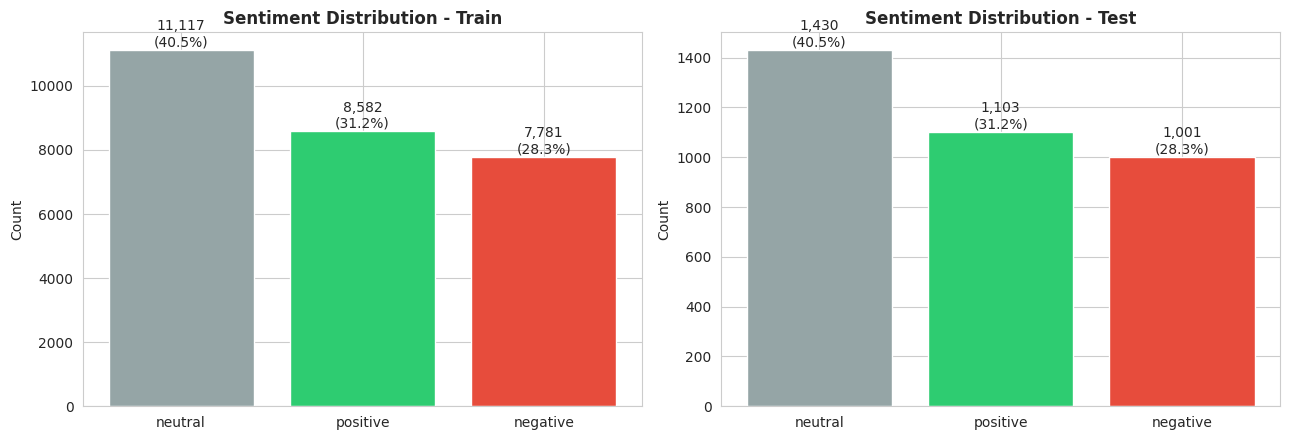

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, df, title in zip(axes, [train, test], ['Train', 'Test']):
    counts = df['sentiment'].value_counts()
    ax.bar(counts.index, counts.values, color=[PALETTE[s] for s in counts.index])
    ax.set_title(f'Sentiment Distribution - {title}', fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values)*0.01,
                f'{v:,}\n({100*v/len(df):.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

**관찰**:
- neutral 40%, positive 31%, negative 28%로 **약한 불균형**.  
- 별도 oversampling 없이 학습해도 무방. 평가지표는 accuracy 외에 **macro-F1**을 함께 봐야 함.

### 4. 텍스트 길이 분포

In [9]:
train['char_len'] = train['text'].str.len()
train['word_len'] = train['text'].str.split().str.len()

print(train[['char_len', 'word_len']].describe().round(1))

       char_len  word_len
count   27480.0   27480.0
mean       68.4      12.9
std        35.6       6.9
min         3.0       1.0
25%        39.0       7.0
50%        64.0      12.0
75%        97.0      18.0
max       159.0      33.0


/tmp/ipykernel_1600/331648100.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='sentiment', y='word_len', ax=axes[1],


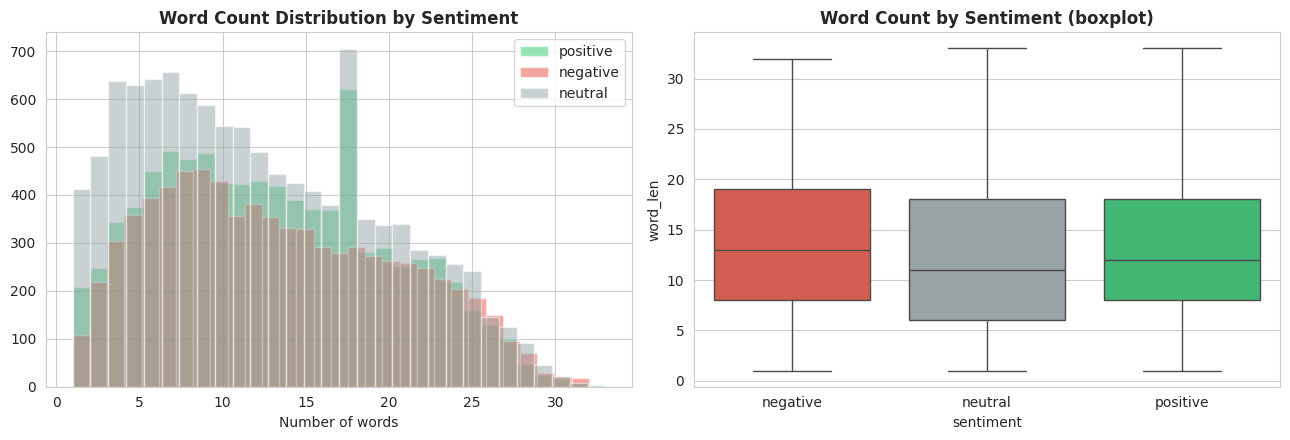

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for sent in ['positive', 'negative', 'neutral']:
    sub = train[train['sentiment'] == sent]
    axes[0].hist(sub['word_len'], bins=30, alpha=0.5, label=sent, color=PALETTE[sent])
axes[0].set_title('Word Count Distribution by Sentiment', fontweight='bold')
axes[0].set_xlabel('Number of words'); axes[0].legend()

sns.boxplot(data=train, x='sentiment', y='word_len', ax=axes[1],
            palette=PALETTE, order=['negative', 'neutral', 'positive'])
axes[1].set_title('Word Count by Sentiment (boxplot)', fontweight='bold')
plt.tight_layout(); plt.show()

**관찰**:
- 트윗 평균 길이는 약 **13단어 (최대 33단어)**.  
- 감정별 길이 차이는 크지 않음.  
- 모델 학습 시 `max_len = 40` 정도면 99% 이상 커버 가능 → 학습 효율 ↑

### 5. 트윗 텍스트 특성 분석

트윗은 URL, 멘션, 해시태그, 이모티콘, 연속 문자(loooove) 등 노이즈가 많다. 전처리 방향을 결정하기 위해 패턴별 빈도를 측정.

In [11]:
patterns = {
    'URL 포함':            r'http\S+|www\.\S+',
    '@멘션 포함':           r'@\w+',
    '#해시태그':            r'#\w+',
    '숫자 포함':            r'\d+',
    '이모티콘 (:) ':        r'[:;=]-?[\)\(\]\[DPp]',
    '느낌표':              r'!',
    '연속 느낌표 (!!)':     r'!{2,}',
    '연속 문자 (loooove)':  r'(\w)\1{2,}',
    'ALL CAPS 단어':       r'\b[A-Z]{3,}\b',
}

rows = []
for label, pat in patterns.items():
    cnt = train['text'].str.contains(pat, regex=True, na=False).sum()
    rows.append({'pattern': label, 'count': cnt, 'percent': 100*cnt/len(train)})

pd.DataFrame(rows).set_index('pattern').round(2)

/tmp/ipykernel_1600/1438900144.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  cnt = train['text'].str.contains(pat, regex=True, na=False).sum()


,count,percent
pattern,,
URL 포함,1283,4.67
@멘션 포함,74,0.27
#해시태그,523,1.90
숫자 포함,4687,17.06
이모티콘 (:),290,1.06
느낌표,8129,29.58
연속 느낌표 (!!),2040,7.42
연속 문자 (loooove),2240,8.15
ALL CAPS 단어,3064,11.15


**전처리 시사점**:  
- **URL은 제거** (의미 없는 토큰) — 약 4.7%  
- **@멘션은 제거 또는 [USER] 토큰화** — 사용자 식별자는 감정과 무관  
- **느낌표는 보존** (29%, 강한 감정 신호)  
- **연속 문자(loooove)는 정규화** (8%, 의미는 유지하되 어휘 크기 절감)  
- **숫자는 보존** (날짜, 수치 표현이 자연스러운 트윗)

### 6. 메타데이터 분석 (Age, Time of Tweet)

데이터셋에는 사용자 연령대, 트윗 작성 시간대, 국가 정보가 있다. 감정과 상관관계가 있는지 확인.

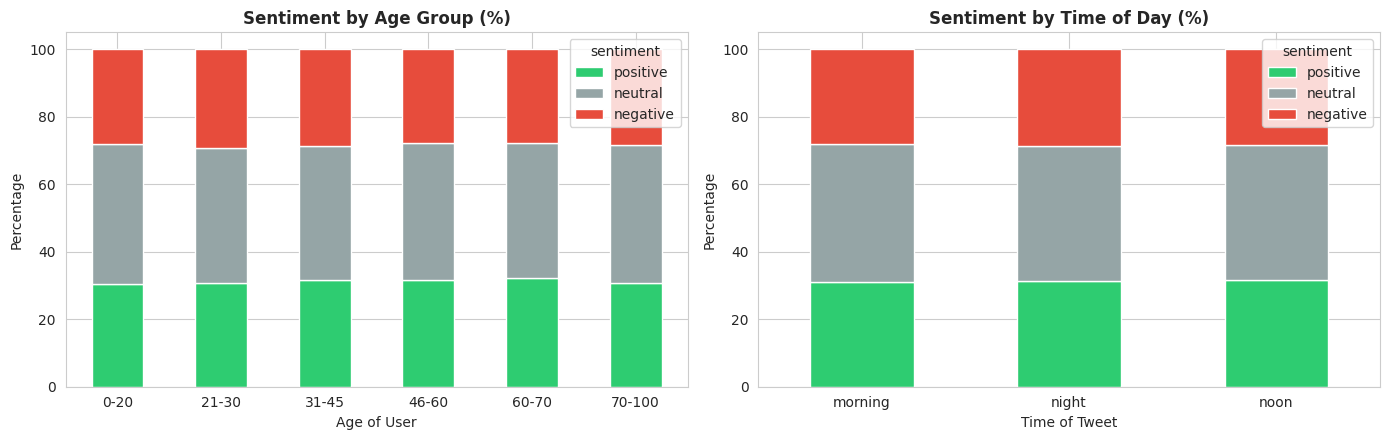

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

age_sent = pd.crosstab(train['Age of User'], train['sentiment'], normalize='index') * 100
age_sent = age_sent[['positive', 'neutral', 'negative']]
age_sent.plot(kind='bar', stacked=True, ax=axes[0],
              color=[PALETTE[c] for c in age_sent.columns])
axes[0].set_title('Sentiment by Age Group (%)', fontweight='bold')
axes[0].set_ylabel('Percentage'); axes[0].tick_params(axis='x', rotation=0)

time_sent = pd.crosstab(train['Time of Tweet'], train['sentiment'], normalize='index') * 100
time_sent = time_sent[['positive', 'neutral', 'negative']]
time_sent.plot(kind='bar', stacked=True, ax=axes[1],
               color=[PALETTE[c] for c in time_sent.columns])
axes[1].set_title('Sentiment by Time of Day (%)', fontweight='bold')
axes[1].set_ylabel('Percentage'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

**관찰**:  
- 연령대·시간대별 감정 분포가 거의 동일  
- → 메타데이터는 감정 예측에 거의 기여하지 않음. **본 과제에서는 text 컬럼만 사용**.  
- (보고서에 "흥미로운 음성 결과"로 언급할 만한 포인트)

### 7. 단어 빈도 분석 (감정별)

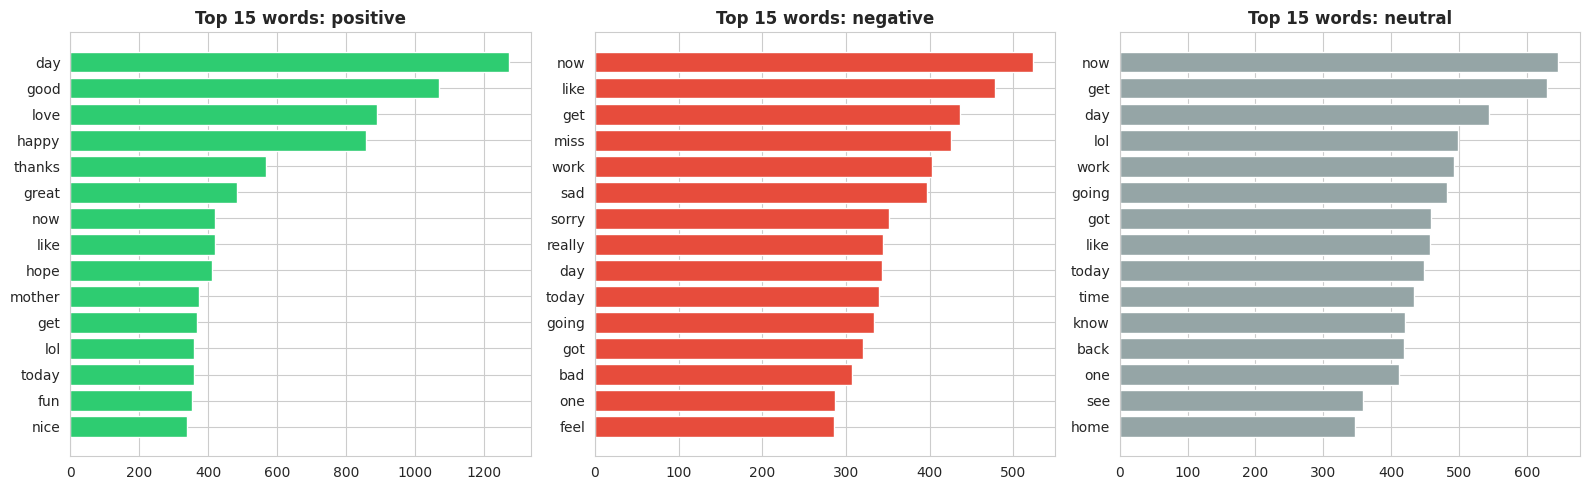

In [13]:
STOPWORDS = set('''i me my we our you your he him his she her it its they them their this that these those
am is are was were be been being have has had do does did a an the and but or if so to of in on at by for
with from as not no nor too very can will just don dont didnt doesnt couldnt wouldnt shouldnt isn aren wasn
weren ll ve re d m s t y about all any been both each few here how into more most other own same some such
than then there what when where which who why up out off down over under again further once because while'''.split())

def simple_tokens(text):
    t = re.sub(r'http\S+|www\.\S+|@\w+', '', text).lower()
    t = re.sub(r'[^a-z\s]', ' ', t)
    return [w for w in t.split() if w not in STOPWORDS and len(w) > 2]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, sent in zip(axes, ['positive', 'negative', 'neutral']):
    words = []
    for t in train[train['sentiment'] == sent]['text']:
        words.extend(simple_tokens(t))
    top = Counter(words).most_common(15)
    w, c = zip(*top)
    ax.barh(range(len(w)), c, color=PALETTE[sent])
    ax.set_yticks(range(len(w))); ax.set_yticklabels(w)
    ax.invert_yaxis()
    ax.set_title(f'Top 15 words: {sent}', fontweight='bold')
plt.tight_layout(); plt.show()

**관찰**:  
- **positive**: day, good, love, happy, thanks, great → 명확한 긍정 표현  
- **negative**: miss, sad, sorry, bad, feel → 명확한 부정 표현  
- **neutral**: now, get, day, lol, work, going → 일상적 단어 위주  
- 단어 수준에서도 클래스 간 구별이 잘 되어 있어 모델 학습 가능성 ↑

### 8. 전처리 파이프라인

두 가지 전처리 함수를 만든다.

| 버전 | 대상 모델 | 처리 강도 | 이유 |
|------|----------|----------|------|
| **Classic** | RNN, LSTM | 강함 (소문자화, 구두점 정리) | 자체 Embedding을 처음부터 학습하므로 노이즈 제거가 성능에 직결 |
| **Transformer** | BERT, GPT | 약함 (URL/멘션만 토큰화) | 사전학습 WordPiece/BPE 토크나이저가 대소문자·구두점을 활용 |

In [14]:
URL_RE      = re.compile(r'http\S+|www\.\S+')
MENTION_RE  = re.compile(r'@\w+')
HTML_RE     = re.compile(r'&\w+;')             # &amp; &lt; 등
REPEAT_RE   = re.compile(r'(.)\1{2,}')         # 'looove' -> 'loove'
MULTI_SPACE = re.compile(r'\s+')

def preprocess_classic(text):
    """RNN/LSTM용 - 강한 정제"""
    t = str(text)
    t = URL_RE.sub(' ', t)
    t = MENTION_RE.sub(' ', t)
    t = HTML_RE.sub(' ', t)
    t = REPEAT_RE.sub(r'\1\1', t)
    t = t.lower()
    t = re.sub(r"[^a-z0-9\s!?'.,]", ' ', t)
    t = MULTI_SPACE.sub(' ', t).strip()
    return t

def preprocess_transformer(text):
    """BERT/GPT용 - 최소 정제"""
    t = str(text)
    t = URL_RE.sub('[URL]', t)
    t = MENTION_RE.sub('[USER]', t)
    t = HTML_RE.sub(' ', t)
    t = REPEAT_RE.sub(r'\1\1', t)
    t = MULTI_SPACE.sub(' ', t).strip()
    return t

In [15]:
# 적용 예시
samples = train.sample(5, random_state=2)[['text', 'sentiment']]
for _, r in samples.iterrows():
    print(f"[{r['sentiment']}]")
    print(f"  원본       : {r['text']}")
    print(f"  classic    : {preprocess_classic(r['text'])}")
    print(f"  transformer: {preprocess_transformer(r['text'])}")
    print()

[negative]
  원본       : This headache is killing me yet I need to cover some boring police event.
  classic    : this headache is killing me yet i need to cover some boring police event.
  transformer: This headache is killing me yet I need to cover some boring police event.

[negative]
  원본       :  Unfortunately, no.
  classic    : unfortunately, no.
  transformer: Unfortunately, no.

[neutral]
  원본       : 92.7 is turning it right about now.
  classic    : 92.7 is turning it right about now.
  transformer: 92.7 is turning it right about now.

[neutral]
  원본       :  I hear you sister!!    Same here.
  classic    : i hear you sister!! same here.
  transformer: I hear you sister!! Same here.

[neutral]
  원본       : time to do some revision while listening to  albums non-stop all day, again!
  classic    : time to do some revision while listening to albums non stop all day, again!
  transformer: time to do some revision while listening to albums non-stop all day, again!



### 9. 전체 데이터에 전처리 적용 + 라벨 인코딩

In [16]:
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}

for name, df in [('train', train), ('test', test)]:
    df['text_classic']     = df['text'].apply(preprocess_classic)
    df['text_transformer'] = df['text'].apply(preprocess_transformer)
    df['label'] = df['sentiment'].map(label_map)
    # 전처리 후 빈 문자열이 된 행 제거
    before = len(df)
    df.drop(df[df['text_classic'].str.len() == 0].index, inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'{name}: {before:,} → {len(df):,} (빈 행 {before-len(df)}개 제거)')

train: 27,480 → 27,477 (빈 행 3개 제거)
test: 3,534 → 3,534 (빈 행 0개 제거)


In [17]:
# 최종 데이터 미리보기
train[['text', 'text_classic', 'text_transformer', 'sentiment', 'label']].head()

,text,text_classic,text_transformer,sentiment,label
0,"I`d have responded, if I were going","i d have responded, if i were going","I`d have responded, if I were going",neutral,1
1,Sooo SAD I will miss you here in San Diego!!!,soo sad i will miss you here in san diego!!,Soo SAD I will miss you here in San Diego!!,negative,0
2,my boss is bullying me...,my boss is bullying me..,my boss is bullying me..,negative,0
3,what interview! leave me alone,what interview! leave me alone,what interview! leave me alone,negative,0
4,"Sons of ****, why couldn`t they put them on the releases we already bought","sons of , why couldn t they put them on the releases we already bought","Sons of **, why couldn`t they put them on the releases we already bought",negative,0


### 10. 클린 데이터 저장 (모델 학습에 사용)

In [18]:
cols = ['text', 'text_classic', 'text_transformer', 'sentiment', 'label']
train[cols].to_csv(os.path.join(DATA_DIR, 'train_clean.csv'), index=False)
test[cols].to_csv(os.path.join(DATA_DIR, 'test_clean.csv'), index=False)

print(f'저장 완료')
print(f'  train_clean.csv: {len(train):,}행')
print(f'  test_clean.csv : {len(test):,}행')
print(f'\nlabel_map = {label_map}')

저장 완료
  train_clean.csv: 27,477행
  test_clean.csv : 3,534행

label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
